Contol Dataset

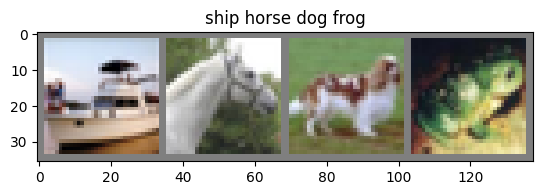

In [15]:
import scipy
import torchvision.transforms as transforms
import torchvision
import matplotlib.pyplot as plt
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader

# from geekforgeek website
test_set = torchvision.datasets.CIFAR10(root='./data', 
                                        train=False, 
                                        download=True,
                                        transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
testloader = torch.utils.data.DataLoader(test_set,
                                          batch_size=4, 
                                          shuffle=True)

images, labels = next(iter(testloader))

plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5); 
plt.title(' '.join(test_set.classes[label] for label in labels)); plt.show()

Generating the control data

The control dataset will act as a wrapper for the pytorch dataset class for memory efficiency (lazy loading). To accomplish this, we must extend the __len__ class and the __getitem__ class which are required in order to work with the torch DataLoader.

In [18]:

class ControlShiftDataset(Dataset):
    def __init__(self, data: Dataset, shift: int = 1, edge_correction: bool = True):
        self.original_dataset = data
        self.shift_by = shift
        self.edge_correction = edge_correction

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        np_img = img.numpy()
        
        shift = (0, self.shift_by, self.shift_by) # shift height and width 
        # what direction tho? 
        
        correction = 'reflect' if self.edge_correction else 'constant'
        shifted_img = scipy.ndimage.shift(np_img, shift=shift, mode=correction, cval=0.0)
        shifted_tensor = torch.from_numpy(shifted_img).float()
        
        return shifted_tensor, label

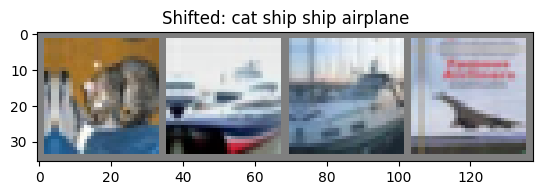

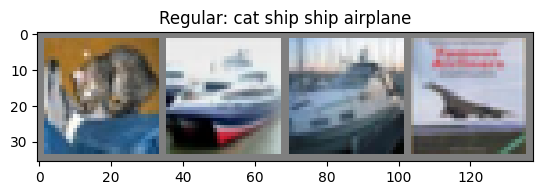

In [32]:
# checking shifted images

test_set_shift_100 = ControlShiftDataset(test_set, shift=3, edge_correction=True)
shifted_loader = DataLoader(test_set_shift_100, batch_size=4, shuffle=False)

# visualise
shifted_images, shifted_labels = next(iter(shifted_loader))
plt.imshow(torchvision.utils.make_grid(shifted_images).permute(1, 2, 0) / 2 + 0.5)
plt.title('Shifted: ' + ' '.join(test_set.classes[label] for label in shifted_labels))
plt.show()

test_set_no_shift = test_set
loader = DataLoader(test_set_no_shift, batch_size=4, shuffle=False)

# visualise
images, labels = next(iter(loader))
plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5)
plt.title('Regular: ' + ' '.join(test_set.classes[label] for label in labels))
plt.show()


